In [186]:
import numpy as np
import pandas as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout
from keras.regularizers import Regularizer
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [187]:
X,y=make_moons(n_samples=100,noise=0.1,random_state=1)

In [188]:
X.shape

(100, 2)

<Axes: >

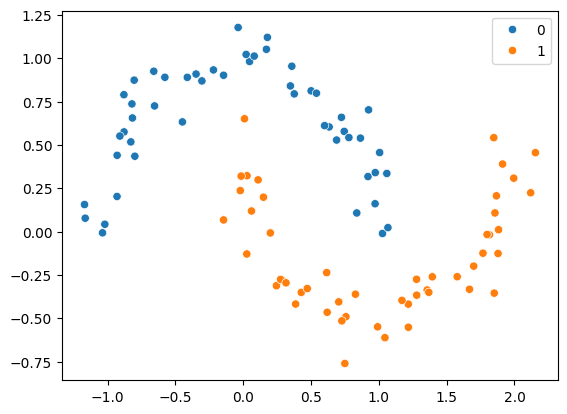

In [189]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)

In [190]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [191]:
y_test.shape

(20,)

In [192]:
model=Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(12,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [193]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [194]:
model.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_47 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 12)             │         1,548 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,945 (7.60 KB)

 Trainable params: 1,945 (7.60 KB)

 Non-trainable params: 0 (0.00 B)

In [195]:
history=model.fit(X_train,y_train,epochs=300,validation_data=(X_test,y_test))

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 461ms/step - accuracy: 0.5500 - loss: 0.6654 - val_accuracy: 0.8000 - val_loss: 0.6344
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7125 - loss: 0.6515 - val_accuracy: 0.8500 - val_loss: 0.6138
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7500 - loss: 0.6371 - val_accuracy: 0.8500 - val_loss: 0.5958
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7500 - loss: 0.6246 - val_accuracy: 0.8500 - val_loss: 0.5771
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7375 - loss: 0.6108 - val_accuracy: 0.8500 - val_loss: 0.5591
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7375 - loss: 0.5981 - val_accuracy: 0.8500 - val_loss: 0.5400
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7625 - loss: 0.5860 - val_accuracy: 0.8500 - val_loss: 0.5209
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7750 - loss: 0.5729 - val_accuracy: 0.8500 - val_loss

Text(0.5, 0, 'epoch')

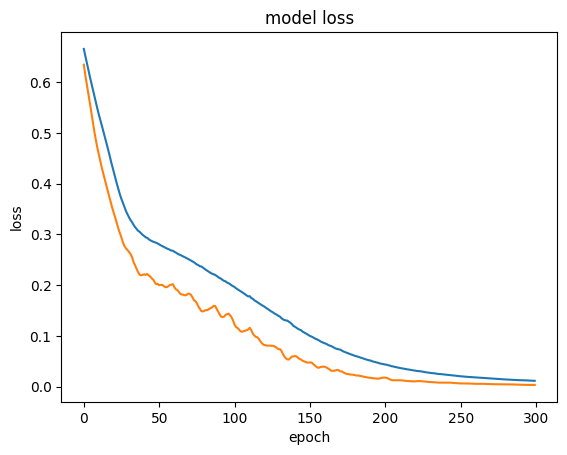

In [196]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


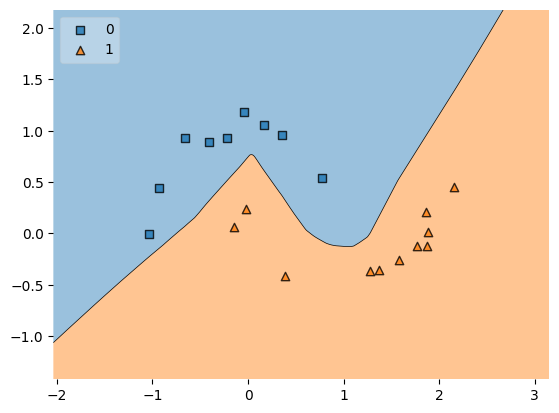

In [197]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

In [198]:
model_weights=model.get_weights()[0].reshape(1,256)

/tmp/ipykernel_5647/898327312.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model_weights)


<Axes: ylabel='Density'>

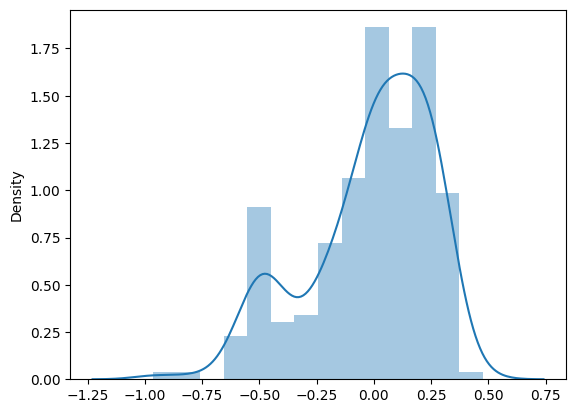

In [199]:
sns.distplot(model_weights)

In [200]:
print(model_weights.max())
print(model_weights.min())

0.4759497
-0.9630795


In [201]:
X,y=make_moons(n_samples=100,noise=0.2,random_state=1)

In [202]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [203]:
from keras import regularizers
model=Sequential()

model.add(Dense(128,activation='relu',input_dim=2,kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(12,activation='relu',kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [204]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [205]:
model.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_50 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 12)             │         1,548 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,945 (7.60 KB)

 Trainable params: 1,945 (7.60 KB)

 Non-trainable params: 0 (0.00 B)

In [206]:
model.fit(X_train,y_train,epochs=300,validation_data=(X_test,y_test))

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 531ms/step - accuracy: 0.4375 - loss: 1.0018 - val_accuracy: 0.3000 - val_loss: 1.0012
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4875 - loss: 0.9666 - val_accuracy: 0.4500 - val_loss: 0.9577
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5250 - loss: 0.9369 - val_accuracy: 0.4500 - val_loss: 0.9240
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5250 - loss: 0.9130 - val_accuracy: 0.4500 - val_loss: 0.8993
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5375 - loss: 0.8933 - val_accuracy: 0.4500 - val_loss: 0.8805
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6750 - loss: 0.8767 - val_accuracy: 0.6500 - val_loss: 0.8647
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7750 - loss: 0.8607 - val_accuracy: 0.7000 - val_loss: 0.8483
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8125 - loss: 0.8463 - val_accuracy: 0.7500 - val_loss

Text(0.5, 0, 'epoch')

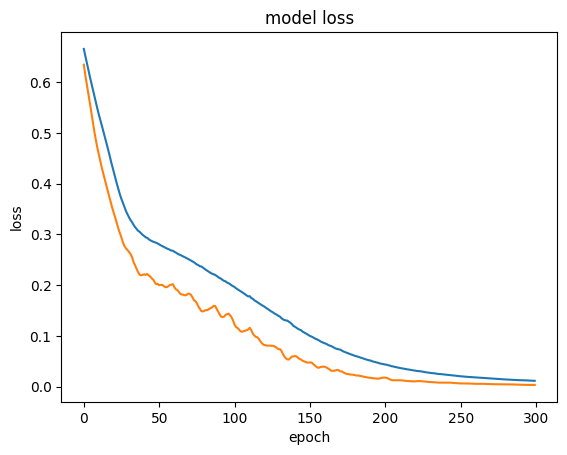

In [207]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


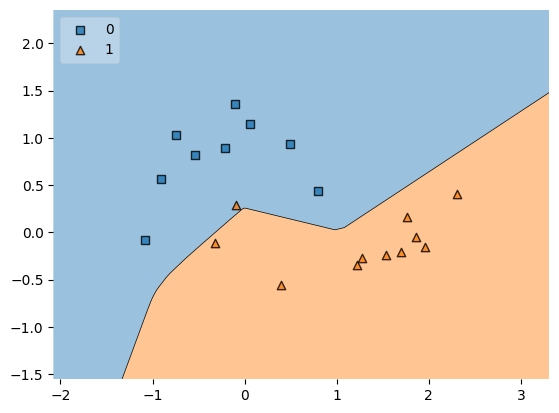

In [208]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

In [209]:
model1_weight=model.get_weights()[0].reshape(1,256)

/tmp/ipykernel_5647/1317115360.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight)


<Axes: ylabel='Density'>

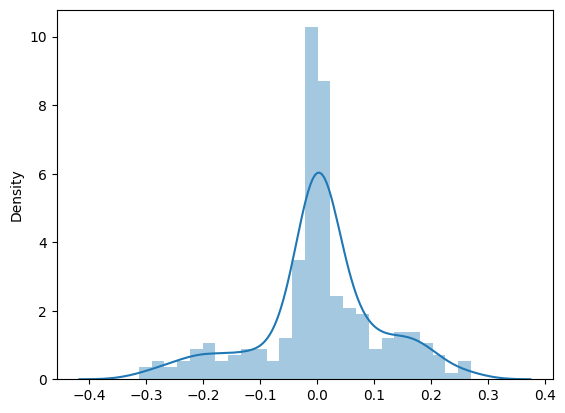

In [210]:
sns.distplot(model1_weight)

In [211]:
model1_weight.max()

np.float32(0.2705501)

In [212]:
model1_weight.min()

np.float32(-0.31277096)